# Peramalan Harga Saham INDF - Model Tunggal CNN
**Model tunggal CNN (tanpa BiLSTM) untuk perbandingan dengan Hybrid CNN-BiLSTM**

Grid parameter:
- n_filters    : [16, 32, 64]
- dropout_rate : [0.1, 0.2, 0.3]
- batch_size   : [16, 32, 64]
- Total: 3 x 3 x 3 = 27 kombinasi x 3 skenario = 81 run


## CELL 1 — Pra-Pemrosesan Data

--- ANALISIS AWAL DATA MENTAH ---
Total Hari Kerja Seharusnya : 2609 hari
Total Data Tersedia         : 2415 hari
Jumlah Data Hilang          : 194 hari


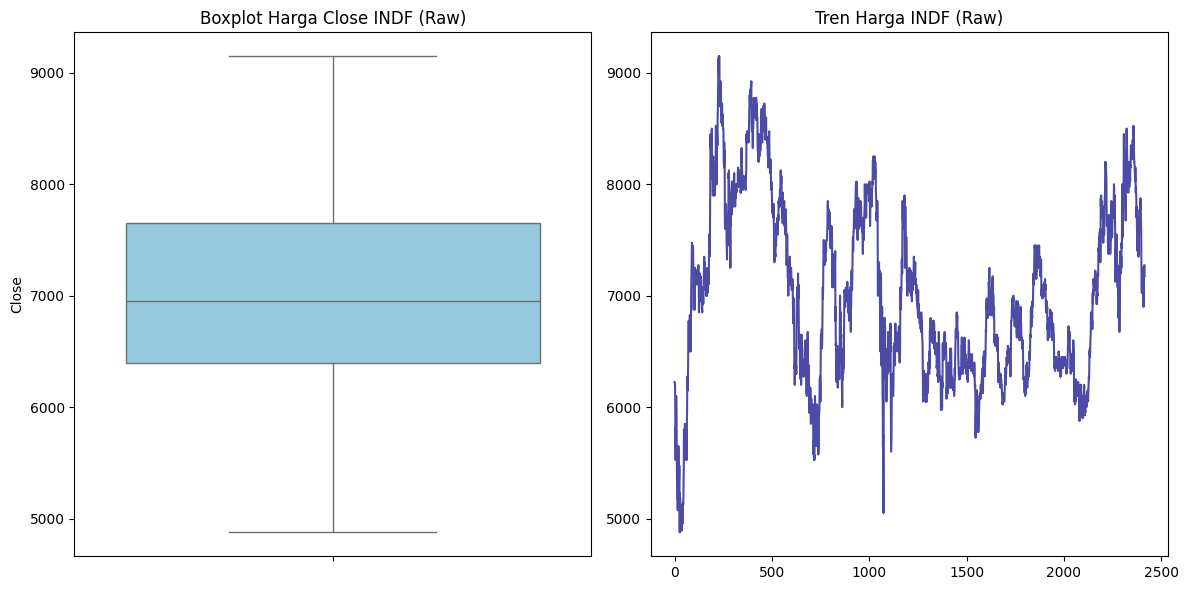


--- HASIL DETEKSI OUTLIER ---
Q1: 6400.0 | Q3: 7650.0 | IQR: 1250.0
Batas Bawah: 4525.0 | Batas Atas: 9525.0
Jumlah Outliers Terdeteksi: 0

✅ Tidak ditemukan outliers pada data mentah.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. LOAD DATA & STANDARISASI KOLOM
df_raw = pd.read_csv('Data Historis INDF.csv', sep=';', thousands='.')
df = df_raw[['Tanggal', 'Terakhir']].rename(columns={'Tanggal': 'Date', 'Terakhir': 'Close'})

# 2. FORMAT TANGGAL & SORTIR
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df = df.sort_values('Date')
df = df.drop_duplicates(subset=['Date'], keep='first')

# 3. IDENTIFIKASI MISSING VALUES (Business Days)
all_business_days = pd.date_range(start=df['Date'].min(), end=df['Date'].max(), freq='B')
missing_dates = all_business_days.difference(df['Date'])

print(f"--- ANALISIS AWAL DATA MENTAH ---")
print(f"Total Hari Kerja Seharusnya : {len(all_business_days)} hari")
print(f"Total Data Tersedia         : {len(df)} hari")
print(f"Jumlah Data Hilang          : {len(missing_dates)} hari")

# 4. DETEKSI OUTLIERS
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.boxplot(y=df['Close'], color='skyblue', ax=axes[0])
axes[0].set_title('Boxplot Harga Close INDF (Raw)')
axes[1].plot(df.index, df['Close'], color='navy', alpha=0.7)
axes[1].set_title('Tren Harga INDF (Raw)')
plt.tight_layout()
plt.show()

Q1 = df['Close'].quantile(0.25)
Q3 = df['Close'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['Close'] < lower_bound) | (df['Close'] > upper_bound)]

print(f"\n--- HASIL DETEKSI OUTLIER ---")
print(f"Q1: {Q1} | Q3: {Q3} | IQR: {IQR}")
print(f"Batas Bawah: {lower_bound} | Batas Atas: {upper_bound}")
print(f"Jumlah Outliers Terdeteksi: {len(outliers)}")
if len(outliers) > 0:
    print("\nDaftar Tanggal Outliers:")
    print(outliers)
else:
    print("\n✅ Tidak ditemukan outliers pada data mentah.")

|| MEMBUAT LIST TANGGAL YANG HILANG / MISSING VALUE ||

In [2]:
import pandas as pd

# 1. Load data mentah
df_raw = pd.read_csv('Data Historis INDF.csv', sep=';', thousands='.')
df_raw['Tanggal'] = pd.to_datetime(df_raw['Tanggal'], format='%d/%m/%Y')
df_raw = df_raw.sort_values('Tanggal')

# 2. Buat rentang hari kerja (Senin-Jumat) dari tanggal awal sampai akhir
full_range = pd.date_range(start=df_raw['Tanggal'].min(), end=df_raw['Tanggal'].max(), freq='B')

# 3. Cari tanggal yang ada di kalender hari kerja tapi tidak ada di dataset
missing_dates = full_range.difference(df_raw['Tanggal'])

# 4. Tampilkan hasil dalam bentuk tabel
missing_dates_df = pd.DataFrame(missing_dates, columns=['Tanggal_Kosong'])
missing_dates_df['Hari'] = missing_dates_df['Tanggal_Kosong'].dt.day_name() # Nama hari dalam Bahasa Inggris

print(f"Total Tanggal yang Hilang: {len(missing_dates_df)} hari")
print("\n--- 20 Tanggal Pertama yang Kosong ---")
print(missing_dates_df.head(20))

# Simpan ke CSV jika Anda ingin melihat daftar lengkapnya (194 hari)
missing_dates_df.to_csv('daftar_tanggal_kosong.csv', index=False)

Total Tanggal yang Hilang: 194 hari

--- 20 Tanggal Pertama yang Kosong ---
   Tanggal_Kosong       Hari
0      2015-12-09  Wednesday
1      2015-12-24   Thursday
2      2015-12-25     Friday
3      2015-12-31   Thursday
4      2016-01-01     Friday
5      2016-02-08     Monday
6      2016-03-09  Wednesday
7      2016-03-25     Friday
8      2016-05-05   Thursday
9      2016-05-06     Friday
10     2016-07-04     Monday
11     2016-07-05    Tuesday
12     2016-07-06  Wednesday
13     2016-07-07   Thursday
14     2016-07-08     Friday
15     2016-08-17  Wednesday
16     2016-09-12     Monday
17     2016-12-12     Monday
18     2016-12-26     Monday
19     2017-01-02     Monday


In [3]:
from sklearn.preprocessing import MinMaxScaler

# 5. REINDEXING & INTERPOLASI
df_indexed = df.set_index('Date')
all_business_days = pd.date_range(start=df_indexed.index.min(), end=df_indexed.index.max(), freq='B')
df_complete = df_indexed.reindex(all_business_days)

# Interpolasi Polinomial Ordo 2
df_complete['Close'] = df_complete['Close'].interpolate(method='polynomial', order=2)
df_complete['Close'] = df_complete['Close'].ffill().bfill()

# 6. NORMALISASI
# Catatan: Normalisasi tetap digunakan meskipun univariate karena membantu
# kestabilan gradient descent pada deep learning (nilai input terbatas 0-1).
# Hasil prediksi akan di-inverse transform kembali ke satuan Rupiah.
scaler_global = MinMaxScaler(feature_range=(0, 1))
df_complete['Close_Scaled'] = scaler_global.fit_transform(df_complete[['Close']])

# Simpan hasil
df_final = df_complete.reset_index().rename(columns={'index': 'Date'})
df_final.to_csv('INDF_Cleaned.csv', index=False)

print(f"✅ Pra-pemrosesan Selesai!")
print(f"Total Baris Akhir : {len(df_final)}")
print(f"Rentang Tanggal   : {df_final['Date'].min()} s/d {df_final['Date'].max()}")
print(f"Data disimpan ke  : 'INDF_Cleaned.csv'")
print(df_final.head())

✅ Pra-pemrosesan Selesai!
Total Baris Akhir : 2609
Rentang Tanggal   : 2015-10-23 00:00:00 s/d 2025-10-22 00:00:00
Data disimpan ke  : 'INDF_Cleaned.csv'
        Date   Close  Close_Scaled
0 2015-10-23  6225.0      0.315789
1 2015-10-26  6225.0      0.315789
2 2015-10-27  6200.0      0.309942
3 2015-10-28  6075.0      0.280702
4 2015-10-29  5650.0      0.181287


## CELL 3 — Load Data & Fungsi Windowing

In [5]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler

tf.random.set_seed(42)
np.random.seed(42)

# Load data bersih
df = pd.read_csv('INDF_Cleaned.csv', parse_dates=['Date'], index_col='Date')
data_full = df[['Close']].values   # Gunakan harga asli (Rupiah)

# Parameter tetap
WINDOW_SIZE = 30

def create_window_dataset(dataset, lookback):
    """Membuat pasangan (X, y) dari data time series dengan sliding window."""
    X, y = [], []
    for i in range(lookback, len(dataset)):
        X.append(dataset[i-lookback:i])
        y.append(dataset[i])
    return np.array(X), np.array(y)

# ==========================================
# INTI: FUNGSI PEMBAGI SKENARIO
# ==========================================
def jalankan_skenario(ratio_train, ratio_val, ratio_test):
    """
    Membagi data, normalisasi, lalu windowing dari data gabungan
    agar konteks antar segmen (train→val→test) tetap terjaga.

    Alur:
      1. Split data mentah (Close) → train / val / test
      2. Fit scaler HANYA pada train → transform val & test
      3. Gabungkan kembali → window dari full scaled
      4. Potong window hasil menjadi 3 bagian sesuai proporsi
    """
    label = f"{int(ratio_train*100)}-{int(ratio_val*100)}-{int(ratio_test*100)}"
    print(f"\n>>> MEMPERSIAPKAN SKENARIO {label} ...")

    n       = len(data_full)
    n_train = int(ratio_train * n)
    n_val   = int(ratio_val   * n)
    n_test  = n - n_train - n_val

    # 1. Split data mentah
    train_raw = data_full[:n_train]
    val_raw   = data_full[n_train : n_train + n_val]
    test_raw  = data_full[n_train + n_val :]

    # 2. Normalisasi — fit HANYA pada train (cegah data leakage)
    scaler = MinMaxScaler(feature_range=(0, 1))
    train_scaled = scaler.fit_transform(train_raw)
    val_scaled   = scaler.transform(val_raw)
    test_scaled  = scaler.transform(test_raw)

    # 3. Gabungkan untuk windowing (konteks antar segmen terjaga)
    full_scaled = np.concatenate([train_scaled, val_scaled, test_scaled])
    X_all, y_all = create_window_dataset(full_scaled, WINDOW_SIZE)

    # 4. Potong kembali sesuai proporsi
    # Jumlah window yang "dimiliki" tiap segmen:
    #   - Train menghasilkan (n_train - WINDOW_SIZE) window
    #   - Val & Test masing-masing menghasilkan n_val dan n_test window
    #     (mereka "meminjam" WINDOW_SIZE terakhir dari segmen sebelumnya sebagai konteks)
    n_train_w = n_train - WINDOW_SIZE
    n_val_w   = n_val
    # n_test_w  = n_test (sisa)

    X_train = X_all[:n_train_w]
    y_train = y_all[:n_train_w]

    X_val   = X_all[n_train_w : n_train_w + n_val_w]
    y_val   = y_all[n_train_w : n_train_w + n_val_w]

    X_test  = X_all[n_train_w + n_val_w :]
    y_test  = y_all[n_train_w + n_val_w :]

    print(f"   Total data      : {n} baris")
    print(f"   Train (mentah)  : {n_train} | Val: {n_val} | Test: {n_test}")
    print(f"   Shape X_train   : {X_train.shape}")
    print(f"   Shape X_val     : {X_val.shape}")
    print(f"   Shape X_test    : {X_test.shape}")

    return {
        'X_train': X_train, 'y_train': y_train,
        'X_val'  : X_val,   'y_val'  : y_val,
        'X_test' : X_test,  'y_test' : y_test,
        'scaler' : scaler
    }

# ==========================================
# EKSEKUSI 3 SKENARIO
# ==========================================
# List skenario: (Train, Val, Test)
skenario_list = [
    (0.80, 0.10, 0.10),
    (0.70, 0.15, 0.15),
    (0.60, 0.20, 0.20)
]

# Dictionary untuk menyimpan semua data siap pakai
datasets = {}

for r_train, r_val, r_test in skenario_list:
    nama = f"{int(r_train*100)}-{int(r_val*100)}-{int(r_test*100)}"
    datasets[nama] = jalankan_skenario(r_train, r_val, r_test)

print("\n✅ Semua skenario siap! Akses: datasets['80-10-10']['X_train']")


>>> MEMPERSIAPKAN SKENARIO 80-10-10 ...
   Total data      : 2609 baris
   Train (mentah)  : 2087 | Val: 260 | Test: 262
   Shape X_train   : (2057, 30, 1)
   Shape X_val     : (260, 30, 1)
   Shape X_test    : (262, 30, 1)

>>> MEMPERSIAPKAN SKENARIO 70-15-15 ...
   Total data      : 2609 baris
   Train (mentah)  : 1826 | Val: 391 | Test: 392
   Shape X_train   : (1796, 30, 1)
   Shape X_val     : (391, 30, 1)
   Shape X_test    : (392, 30, 1)

>>> MEMPERSIAPKAN SKENARIO 60-20-20 ...
   Total data      : 2609 baris
   Train (mentah)  : 1565 | Val: 521 | Test: 523
   Shape X_train   : (1535, 30, 1)
   Shape X_val     : (521, 30, 1)
   Shape X_test    : (523, 30, 1)

✅ Semua skenario siap! Akses: datasets['80-10-10']['X_train']


## CELL 5 - Definisi Arsitektur Model CNN (Tunggal)


In [6]:
import time
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv1D, MaxPooling1D,
                                     Dense, Dropout, Flatten)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

tf.random.set_seed(42)
np.random.seed(42)

def bangun_model(window_size, n_filters, dropout_rate):
    model = Sequential(name=f'CNN_f{n_filters}')
    model.add(Conv1D(filters=n_filters, kernel_size=3, activation='relu',
                     padding='same', input_shape=(window_size, 1)))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(dropout_rate))
    model.add(Flatten())
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(dropout_rate))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

def hitung_metrik(y_true_scaled, y_pred_scaled, scaler):
    y_true = scaler.inverse_transform(y_true_scaled.reshape(-1, 1)).flatten()
    y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2   = r2_score(y_true, y_pred)
    return mae, rmse, mape, r2

print('Fungsi model CNN tunggal siap digunakan.')


Fungsi model CNN tunggal siap digunakan.


## CELL 6 - Hyperparameter Tuning CNN (Grid Search)

Grid: n_filters [16,32,64] x dropout [0.1,0.2,0.3] x batch_size [16,32,64]
= 27 kombinasi x 3 skenario = 81 run


In [6]:
from itertools import product
import os

os.makedirs('models', exist_ok=True)

param_grid = {
    'n_filters'    : [16, 32, 64],
    'dropout_rate' : [0.1, 0.2, 0.3],
    'batch_size'   : [16, 32, 64],
}

EPOCHS   = 30
PATIENCE = 10
skenario_list = ['80-10-10', '70-15-15', '60-20-20']

kombinasi = list(product(
    param_grid['n_filters'],
    param_grid['dropout_rate'],
    param_grid['batch_size'],
))

total_kombi    = len(kombinasi)
total_skenario = len(skenario_list)
total_run      = total_kombi * total_skenario

print('=' * 70)
print('  HYPERPARAMETER TUNING CNN (TUNGGAL)')
print(f'  {total_kombi} kombinasi x {total_skenario} skenario = {total_run} total run')
print('=' * 70)

hasil_tuning  = []
history_tuning = {}  # simpan history per top 1
model_final   = {}   # simpan model top 1 per skenario

for nama_skenario in skenario_list:
    data    = datasets[nama_skenario]
    X_train = data['X_train']
    y_train = data['y_train']
    X_val   = data['X_val']
    y_val   = data['y_val']
    X_test  = data['X_test']
    y_test  = data['y_test']
    scaler  = data['scaler']

    print(f'\n>>> SKENARIO {nama_skenario}')
    print('-' * 70)

    best_mape_skenario = float('inf')
    best_model_skenario = None
    best_history_skenario = None
    best_nama_skenario = None

    for idx, (n_filters, dropout, batch_size) in enumerate(kombinasi, 1):
        tf.keras.backend.clear_session()

        nama = f'f{n_filters}_d{int(dropout*10)}_b{batch_size}'
        print(f'  [{idx:02d}/{total_kombi}] {nama} ...', end=' ')

        model = bangun_model(
            window_size  = WINDOW_SIZE,
            n_filters    = n_filters,
            dropout_rate = dropout
        )

        early_stop = EarlyStopping(
            monitor='val_loss', patience=PATIENCE,
            restore_best_weights=True, verbose=0
        )

        waktu_mulai = time.time()
        history = model.fit(
            X_train, y_train,
            epochs          = EPOCHS,
            batch_size      = batch_size,
            validation_data = (X_val, y_val),
            callbacks       = [early_stop],
            verbose         = 0
        )
        durasi_detik   = time.time() - waktu_mulai
        epoch_berhenti = len(history.history['loss'])

        y_pred = model.predict(X_test, verbose=0)
        mae, rmse, mape, r2 = hitung_metrik(y_test, y_pred, scaler)

        hasil_tuning.append({
            'Nama'          : nama,
            'Skenario'      : nama_skenario,
            'Filter CNN'    : n_filters,
            'Dropout'       : dropout,
            'Batch Size'    : batch_size,
            'Epoch Berhenti': epoch_berhenti,
            'Waktu (detik)' : round(durasi_detik, 2),
            'MAE'           : round(mae, 4),
            'RMSE'          : round(rmse, 4),
            'MAPE (%)'      : round(mape, 4),
            'R2'            : round(r2, 4),
        })

        print(f'Epoch: {epoch_berhenti} | Waktu: {durasi_detik:.2f} dtk | MAPE: {mape:.4f}% | R2: {r2:.4f}')

        # Simpan model terbaik per skenario (Opsi A)
        if mape < best_mape_skenario:
            best_mape_skenario    = mape
            best_model_skenario   = model
            best_history_skenario = history.history
            best_nama_skenario    = nama

    # Simpan model & history top 1 skenario ini
    key = f'{best_nama_skenario}_{nama_skenario}'
    model_final[key]    = best_model_skenario
    history_tuning[key] = best_history_skenario
    best_model_skenario.save(f'models/top1_{nama_skenario}_CNN.keras')
    print(f'  ✅ Model top 1 skenario {nama_skenario} disimpan: {key}')

df_tuning = pd.DataFrame(hasil_tuning)
df_tuning.to_csv('hasil_tuning_CNN.csv', index=False)

# Top 1 per skenario
print('\n' + '=' * 70)
print('  TOP 1 KONFIGURASI PER SKENARIO - CNN')
print('=' * 70)
top1_per_skenario = {}
for nama_skenario in skenario_list:
    subset = df_tuning[df_tuning['Skenario'] == nama_skenario]
    top1   = subset.loc[subset['MAPE (%)'].idxmin()]
    top1_per_skenario[nama_skenario] = top1
    print(f'  {nama_skenario} -> {top1["Nama"]} | '
          f'MAE: {top1["MAE"]} | RMSE: {top1["RMSE"]} | MAPE: {top1["MAPE (%)"]}% | R2: {top1["R2"]}')

# Top 1 keseluruhan
best_overall = df_tuning.loc[df_tuning['MAPE (%)'].idxmin()]
print('\n' + '=' * 70)
print('  KONFIGURASI TERBAIK KESELURUHAN - CNN')
print('=' * 70)
print(f'  Nama         : {best_overall["Nama"]}')
print(f'  Skenario     : {best_overall["Skenario"]}')
print(f'  Filter CNN   : {int(best_overall["Filter CNN"])}')
print(f'  Dropout      : {best_overall["Dropout"]}')
print(f'  Batch Size   : {int(best_overall["Batch Size"])}')
print(f'  MAE          : {best_overall["MAE"]}')
print(f'  RMSE         : {best_overall["RMSE"]}')
print(f'  MAPE         : {best_overall["MAPE (%)"]}%')
print(f'  R2           : {best_overall["R2"]}')
print(f'  Waktu        : {best_overall["Waktu (detik)"]} detik')
print("\n✅ Hasil tuning disimpan ke: 'hasil_tuning_CNN.csv'")

# Siapkan variabel untuk cell berikutnya
konfigurasi_terbaik = {
    'nama'        : best_overall['Nama'],
    'n_filters'   : int(best_overall['Filter CNN']),
    'dropout_rate': float(best_overall['Dropout']),
    'batch_size'  : int(best_overall['Batch Size']),
}
best_skenario = best_overall['Skenario']
best_key      = f"{best_overall['Nama']}_{best_overall['Skenario']}"
best_mape     = best_overall['MAPE (%)']
best_mae      = best_overall['MAE']
best_rmse     = best_overall['RMSE']
best_r2       = best_overall['R2']
best_label    = f"CNN ({best_overall['Nama']})"
skenario_final = ['80-10-10', '70-15-15', '60-20-20']

# df_final_hasil dari top1 per skenario
df_final_hasil = pd.DataFrame([
    {
        'Konfigurasi'   : top1_per_skenario[s]['Nama'],
        'Skenario'      : s,
        'Epoch Berhenti': top1_per_skenario[s]['Epoch Berhenti'],
        'Waktu (detik)' : top1_per_skenario[s]['Waktu (detik)'],
        'MAE'           : top1_per_skenario[s]['MAE'],
        'RMSE'          : top1_per_skenario[s]['RMSE'],
        'MAPE (%)'      : top1_per_skenario[s]['MAPE (%)'],
        'R2'            : top1_per_skenario[s]['R2'],
    }
    for s in skenario_final
])
df_final_hasil.to_csv('hasil_training_final_CNN.csv', index=False)
print('\nRekap performa top 1 per skenario:')
print(df_final_hasil.to_string(index=False))


  HYPERPARAMETER TUNING CNN (TUNGGAL)
  27 kombinasi x 3 skenario = 81 total run

>>> SKENARIO 80-10-10
----------------------------------------------------------------------

  [01/27] f16_d1_b16 ... 

C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch: 30 | Waktu: 13.50 dtk | MAPE: 1.7509% | R2: 0.7628
  [02/27] f16_d1_b32 ... 

C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch: 24 | Waktu: 7.88 dtk | MAPE: 1.8348% | R2: 0.7210
  [03/27] f16_d1_b64 ... 

...

Epoch: 30 | Waktu: 12.88 dtk | MAPE: 1.3048% | R2: 0.9629
  [26/27] f64_d3_b32 ... 

C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch: 26 | Waktu: 10.12 dtk | MAPE: 1.3080% | R2: 0.9626
  [27/27] f64_d3_b64 ... 

C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch: 30 | Waktu: 7.95 dtk | MAPE: 1.4021% | R2: 0.9582
  ✅ Model top 1 skenario 60-20-20 disimpan: f32_d1_b16_60-20-20

  TOP 1 KONFIGURASI PER SKENARIO - CNN
  80-10-10 -> f64_d2_b64 | MAE: 122.3424 | RMSE: 175.0973 | MAPE: 1.5957% | R2: 0.79
  70-15-15 -> f64_d1_b64 | MAE: 98.8912 | RMSE: 145.0655 | MAPE: 1.3402% | R2: 0.9605
  60-20-20 -> f32_d1_b16 | MAE: 85.4265 | RMSE: 127.3318 | MAPE: 1.1824% | R2: 0.9702

  KONFIGURASI TERBAIK KESELURUHAN - CNN
  Nama         : f32_d1_b16
  Skenario     : 60-20-20
  Filter CNN   : 32
  Dropout      : 0.1
  Batch Size   : 16
  MAE          : 85.4265
  RMSE         : 127.3318
  MAPE         : 1.1824%
  R2           : 0.9702
  Waktu        : 15.9 detik

✅ Hasil tuning disimpan ke: 'hasil_tuning_CNN.csv'

Rekap performa top 1 per skenario:
Konfigurasi Skenario  Epoch Berhenti  Waktu (detik)      MAE     RMSE  MAPE (%)     R2
 f64_d2_b64 80-10-10              30           7.44 122.3424 175.0973    1.5957 0.7900
 f64_d1_b64 70-15-15              30

## CELL 7 — Visualisasi Trade-Off Tuning

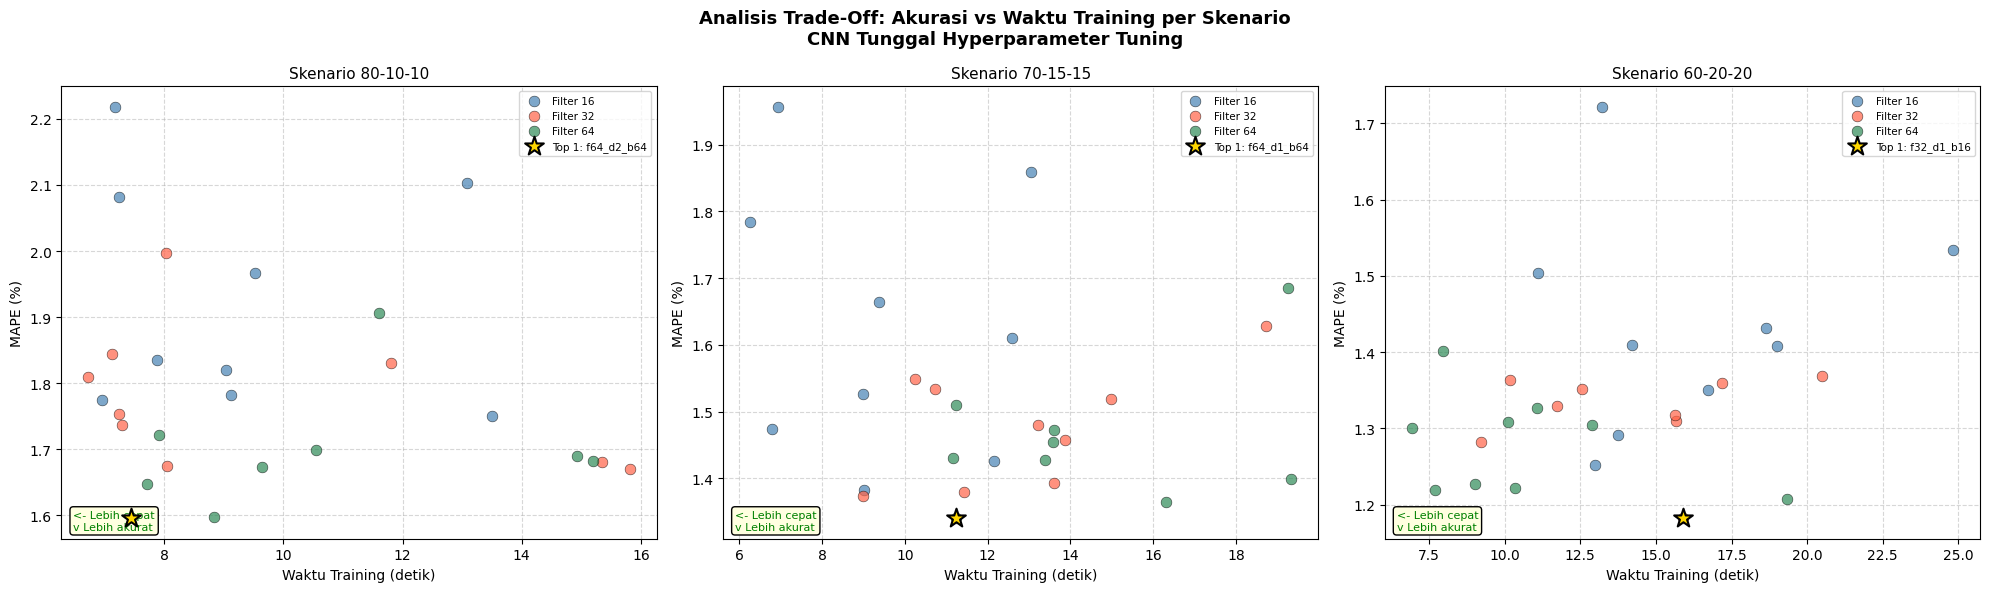

✅ Grafik trade-off disimpan ke: 'tradeoff_tuning_CNN.png'


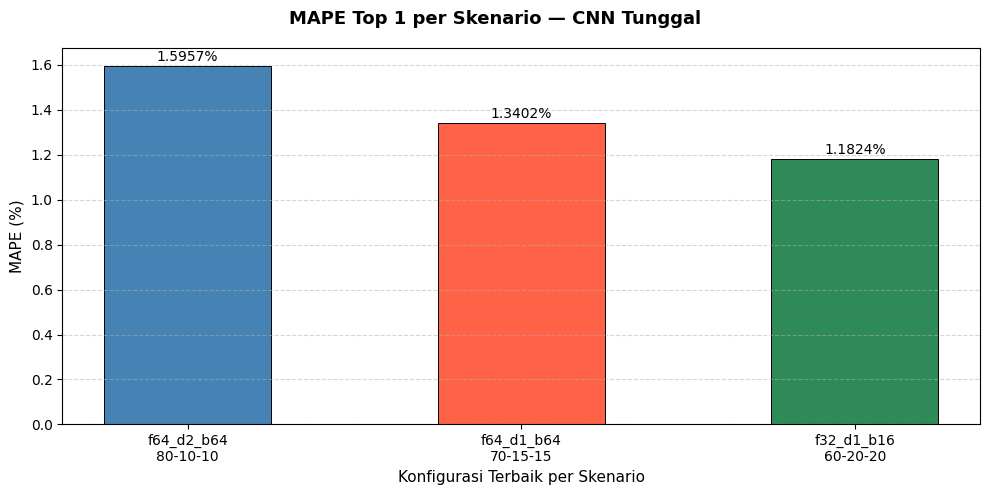

✅ Grafik top 1 per skenario disimpan ke: 'top1_per_skenario_CNN.png'


In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(
    'Analisis Trade-Off: Akurasi vs Waktu Training per Skenario\n'
    'CNN Tunggal Hyperparameter Tuning',
    fontsize=13, fontweight='bold'
)

colors_filter = {16: 'steelblue', 32: 'tomato', 64: 'seagreen'}

for col_idx, nama_skenario in enumerate(skenario_list):
    ax     = axes[col_idx]
    subset = df_tuning[df_tuning['Skenario'] == nama_skenario]
    top1   = top1_per_skenario[nama_skenario]

    for n_filter in [16, 32, 64]:
        s = subset[subset['Filter CNN'] == n_filter]
        ax.scatter(
            s['Waktu (detik)'], s['MAPE (%)'],
            c=colors_filter[n_filter],
            label=f'Filter {n_filter}',
            s=60, edgecolors='black', linewidths=0.4, alpha=0.7, zorder=3
        )

    # Highlight top 1
    ax.scatter(
        [top1['Waktu (detik)']], [top1['MAPE (%)']],
        c='gold', s=200, edgecolors='black',
        linewidths=1.5, zorder=5, marker='*',
        label=f"Top 1: {top1['Nama']}"
    )

    ax.set_title(f'Skenario {nama_skenario}', fontsize=11)
    ax.set_xlabel('Waktu Training (detik)', fontsize=10)
    ax.set_ylabel('MAPE (%)', fontsize=10)
    ax.legend(fontsize=7.5)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.annotate(
        '<- Lebih cepat\nv Lebih akurat',
        xy=(0.02, 0.02), xycoords='axes fraction',
        fontsize=8, color='green',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow')
    )

plt.tight_layout()
plt.savefig('tradeoff_tuning_CNN.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik trade-off disimpan ke: 'tradeoff_tuning_CNN.png'")

# Bar chart top 1 per skenario
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('MAPE Top 1 per Skenario — CNN Tunggal', fontsize=13, fontweight='bold')

nama_list = [top1_per_skenario[s]['Nama'] + '\n' + s for s in skenario_list]
mape_list = [top1_per_skenario[s]['MAPE (%)'] for s in skenario_list]
bars      = ax.bar(nama_list, mape_list, color=['steelblue', 'tomato', 'seagreen'],
                   edgecolor='black', linewidth=0.7, width=0.5)

for bar, val in zip(bars, mape_list):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f'{val:.4f}%', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('MAPE (%)', fontsize=11)
ax.set_xlabel('Konfigurasi Terbaik per Skenario', fontsize=11)
ax.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('top1_per_skenario_CNN.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik top 1 per skenario disimpan ke: 'top1_per_skenario_CNN.png'")

## CELL 9 — Loss Curve (Training vs Validation)


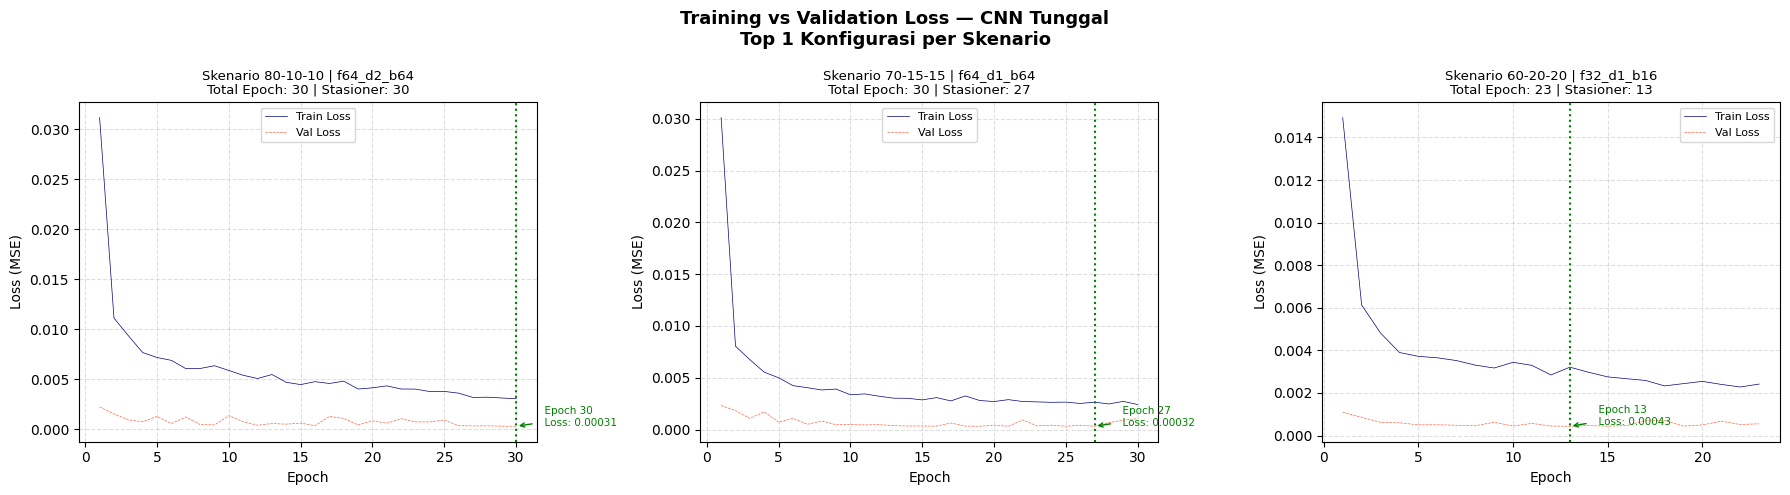

✅ Loss curve disimpan ke: loss_curve_CNN.png


In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Gunakan history dari tuning (top 1 per skenario)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'Training vs Validation Loss — CNN Tunggal\n'
    f'Top 1 Konfigurasi per Skenario',
    fontsize=13, fontweight='bold'
)

for col_idx, nama_skenario in enumerate(skenario_final):
    # Cari key top 1 untuk skenario ini
    top1_nama = top1_per_skenario[nama_skenario]['Nama']
    key = f'{top1_nama}_{nama_skenario}'
    ax  = axes[col_idx]
    h   = history_tuning[key]

    total_epoch   = len(h['loss'])
    val_loss_arr  = np.array(h['val_loss'])
    best_epoch    = int(np.argmin(val_loss_arr)) + 1
    best_val_loss = val_loss_arr[best_epoch - 1]

    ax.plot(range(1, total_epoch + 1), h['loss'],
            label='Train Loss', color='navy', linewidth=0.5)
    ax.plot(range(1, total_epoch + 1), h['val_loss'],
            label='Val Loss', color='tomato',
            linewidth=0.5, linestyle='--')

    ax.axvline(x=best_epoch, color='green', linestyle=':', linewidth=1.5)
    ax.annotate(
        f'  Epoch {best_epoch}\n  Loss: {best_val_loss:.5f}',
        xy=(best_epoch, best_val_loss),
        xytext=(best_epoch + total_epoch * 0.05, best_val_loss * 1.15),
        fontsize=7.5, color='green',
        arrowprops=dict(arrowstyle='->', color='green', lw=1)
    )

    ax.set_title(
        f'Skenario {nama_skenario} | {top1_nama}\n'
        f'Total Epoch: {total_epoch} | Stasioner: {best_epoch}',
        fontsize=9.5
    )
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss (MSE)')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('loss_curve_CNN.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Loss curve disimpan ke: loss_curve_CNN.png')


## CELL 10 — Perbandingan Metrik Evaluasi (Bar Chart)

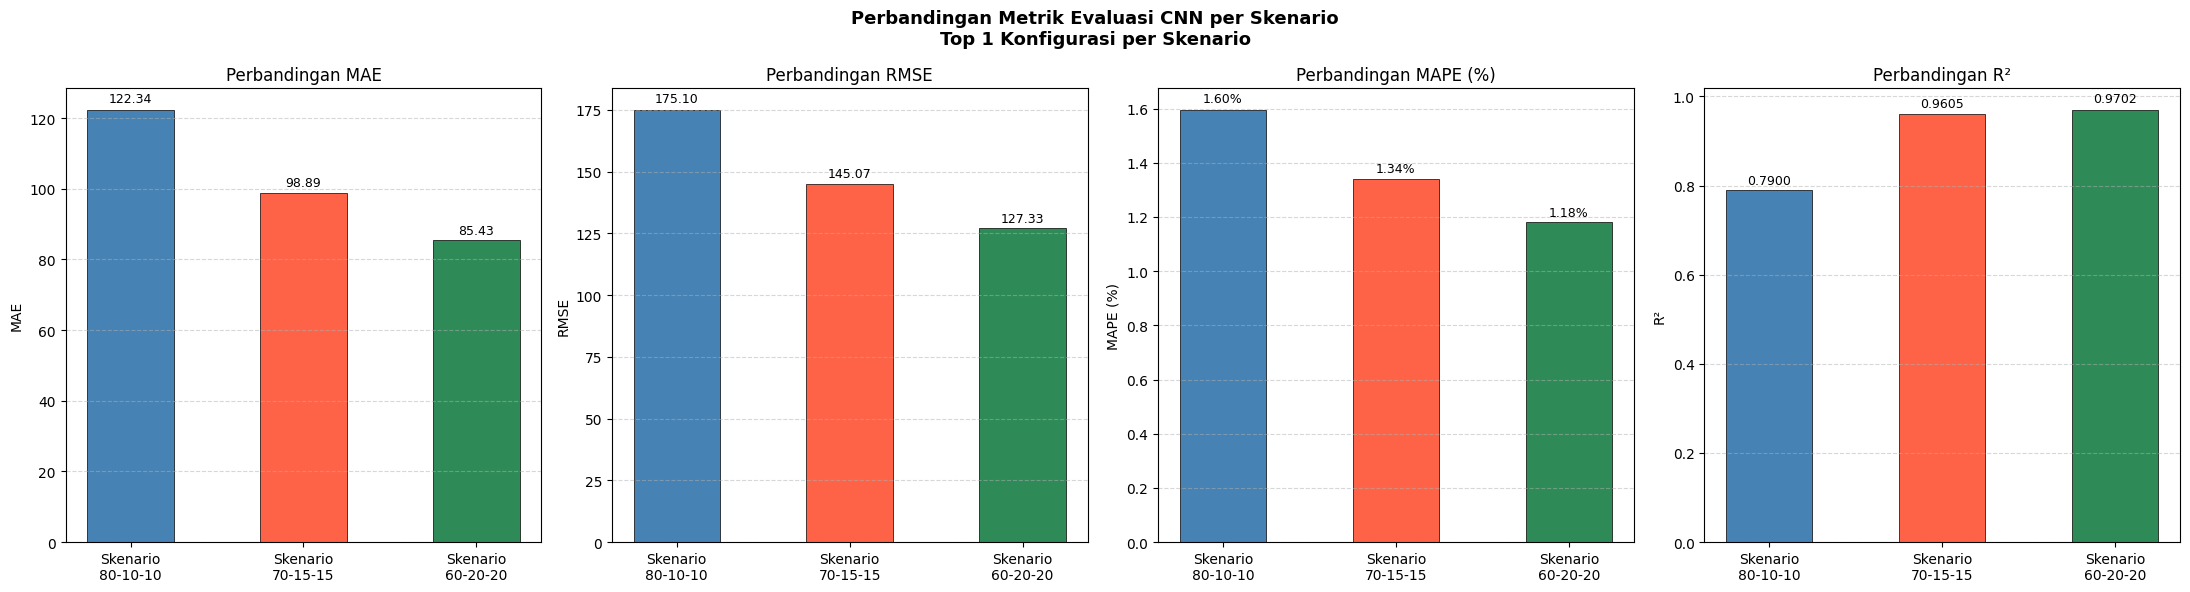


🏆 Performa terbaik CNN:
   Skenario      : 60-20-20
   Konfigurasi   : f32_d1_b16
   MAE           : 85.43
   RMSE          : 127.33
   MAPE          : 1.1824%
   R²           : 0.9702
   Waktu Training: 15.9 detik


In [9]:
fig, axes = plt.subplots(1, 4, figsize=(22, 6))
fig.suptitle(
    f'Perbandingan Metrik Evaluasi CNN per Skenario\n'
    f'Top 1 Konfigurasi per Skenario',
    fontsize=13, fontweight='bold'
)

metrik_list  = ['MAE', 'RMSE', 'MAPE (%)', 'R2']
metrik_label = ['MAE', 'RMSE', 'MAPE (%)', 'R\u00b2']
bar_colors   = ['steelblue', 'tomato', 'seagreen']

# Pastikan urutan skenario konsisten
df_plot = df_final_hasil.set_index('Skenario').loc[skenario_final].reset_index()

for i, (metrik, label) in enumerate(zip(metrik_list, metrik_label)):
    ax   = axes[i]
    vals = df_plot[metrik].values

    bars = ax.bar(
        [f'Skenario\n{s}' for s in skenario_final],
        vals, color=bar_colors,
        edgecolor='black', linewidth=0.5, width=0.5
    )

    for bar, val in zip(bars, vals):
        if metrik == 'MAPE (%)':
            txt = f'{val:.2f}%'
        elif metrik == 'R2':
            txt = f'{val:.4f}'
        else:
            txt = f'{val:.2f}'
        ax.text(bar.get_x() + bar.get_width()/2,
                val + 0.01 * val,
                txt, ha='center', va='bottom', fontsize=9)

    ax.set_ylabel(label)
    ax.set_title(f'Perbandingan {label}')
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('evaluasi_perbandingan_CNN.png', dpi=150, bbox_inches='tight')
plt.show()

best_row = df_final_hasil.loc[df_final_hasil['MAPE (%)'].idxmin()]
print(f'\n\U0001f3c6 Performa terbaik CNN:')
print(f"   Skenario      : {best_row['Skenario']}")
print(f"   Konfigurasi   : {best_row['Konfigurasi']}")
print(f"   MAE           : {best_row['MAE']:.2f}")
print(f"   RMSE          : {best_row['RMSE']:.2f}")
print(f"   MAPE          : {best_row['MAPE (%)']}%")
print(f"   R\u00b2           : {best_row['R2']:.4f}")
print(f"   Waktu Training: {best_row['Waktu (detik)']} detik")


In [ ]:
# KALO KERNEL DI RESTART LAGI RUN CELL LOAD, ARSITEKTUR MODEL DAN CELL INI AJA
# ==========================================

import tensorflow as tf
import pandas as pd

df_tuning      = pd.read_csv('hasil_tuning_CNN.csv')
df_final_hasil = pd.read_csv('hasil_training_final_CNN.csv')

skenario_final = ['80-10-10', '70-15-15', '60-20-20']
top1_per_skenario = {}
for s in skenario_final:
    subset = df_tuning[df_tuning['Skenario'] == s]
    top1_per_skenario[s] = subset.loc[subset['MAPE (%)'].idxmin()]

# Load model dari file
model_final = {}
for s in skenario_final:
    nama = top1_per_skenario[s]['Nama']
    key  = f"{nama}_{s}"
    model_final[key] = tf.keras.models.load_model(f'models/top1_{s}_CNN.keras')
    print(f"✅ Model loaded: {key}")

✅ Model loaded: f64_d2_b64_80-10-10
✅ Model loaded: f64_d1_b64_70-15-15
✅ Model loaded: f32_d1_b16_60-20-20


## CELL 11 — Visualisasi Prediksi vs Aktual (1 Grafik Terbaik)

**Revisi:** Hanya menampilkan 1 grafik dari model dengan MAPE terkecil,
bukan semua 6 kombinasi.

Model terbaik: f32_d1_b16_60-20-20
MAE: 85.43 | RMSE: 127.33 | MAPE: 1.1824% | R2: 0.9702 | Waktu: 15.9 dtk


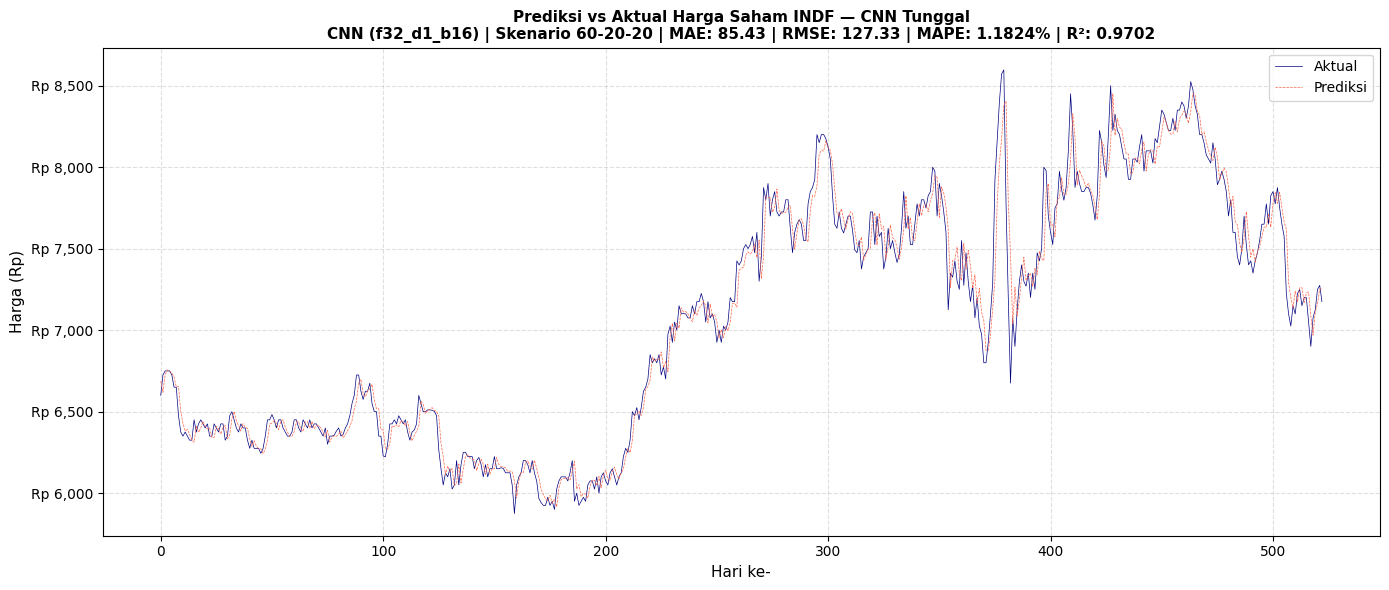

Grafik prediksi disimpan ke: prediksi_vs_aktual_terbaik_CNN.png


In [9]:
import matplotlib.pyplot as plt
best_idx      = df_final_hasil['MAPE (%)'].idxmin()
best_row      = df_final_hasil.loc[best_idx]
best_key      = f"{best_row['Konfigurasi']}_{best_row['Skenario']}"
best_skenario = best_row['Skenario']
best_label    = f"CNN ({best_row['Konfigurasi']})"
best_mape     = best_row['MAPE (%)']
best_mae      = best_row['MAE']
best_rmse     = best_row['RMSE']
best_r2       = best_row['R2']
best_waktu    = best_row['Waktu (detik)']

print(f'Model terbaik: {best_key}')
print(f'MAE: {best_mae:.2f} | RMSE: {best_rmse:.2f} | MAPE: {best_mape:.4f}% | R2: {best_r2:.4f} | Waktu: {best_waktu} dtk')

data = datasets[best_skenario]

y_pred_scaled = model_final[best_key].predict(data['X_test'], verbose=0)

y_true = data['scaler'].inverse_transform(data['y_test'].reshape(-1, 1)).flatten()
y_pred = data['scaler'].inverse_transform(y_pred_scaled).flatten()

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(y_true, label='Aktual', color='navy', linewidth=0.5)
ax.plot(y_pred, label='Prediksi', color='tomato', linewidth=0.5, linestyle='--')

ax.set_title(
    f'Prediksi vs Aktual Harga Saham INDF — CNN Tunggal\n'
    f'{best_label} | Skenario {best_skenario} | '
    f'MAE: {best_mae:.2f} | RMSE: {best_rmse:.2f} | MAPE: {best_mape:.4f}% | R²: {best_r2:.4f}',
    fontsize=11, fontweight='bold'
)
ax.set_xlabel('Hari ke-', fontsize=11)
ax.set_ylabel('Harga (Rp)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp {int(x):,}'))

plt.tight_layout()
plt.savefig('prediksi_vs_aktual_terbaik_CNN.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik prediksi disimpan ke: prediksi_vs_aktual_terbaik_CNN.png')


## CELL 13 — Prediksi 1 Hari & 30 Hari ke Depan

Kedua prediksi dijalankan dalam 1 cell menggunakan strategi **recursive forecasting**:
- Loop 30 iterasi, iterasi pertama = prediksi 1 hari (23 Oktober 2025)
- Setiap hasil prediksi dianggap aktual dan dimasukkan ke window berikutnya
- Output: prediksi 1 hari + tabel & grafik prediksi 30 hari


  PREDIKSI HARGA SAHAM INDF — 1 HARI KE DEPAN
  Model            : f32_d1_b16_60-20-20
  Data terakhir    : 22 October 2025 | Harga: Rp 7,175
  Tanggal prediksi : 23 October 2025
  Prediksi Harga   : Rp 7,159.03
  Selisih          : Rp 15.97 (turun)

  PREDIKSI HARGA SAHAM INDF — 30 HARI KE DEPAN
  Model    : f32_d1_b16_60-20-20
  Strategi : Recursive Forecasting
  Mulai    : 23 October 2025
  Selesai  : 03 December 2025
         Tanggal  Prediksi (Rp)
 23 October 2025    7159.029785
 24 October 2025    7160.399902
 27 October 2025    7176.620117
 28 October 2025    7189.109863
 29 October 2025    7210.049805
 30 October 2025    7220.549805
 31 October 2025    7205.970215
03 November 2025    7197.839844
04 November 2025    7178.160156
05 November 2025    7161.419922
06 November 2025    7157.720215
07 November 2025    7157.569824
10 November 2025    7129.569824
11 November 2025    7110.459961
12 November 2025    7098.169922
13 November 2025    7089.140137
14 November 2025    7071.879883

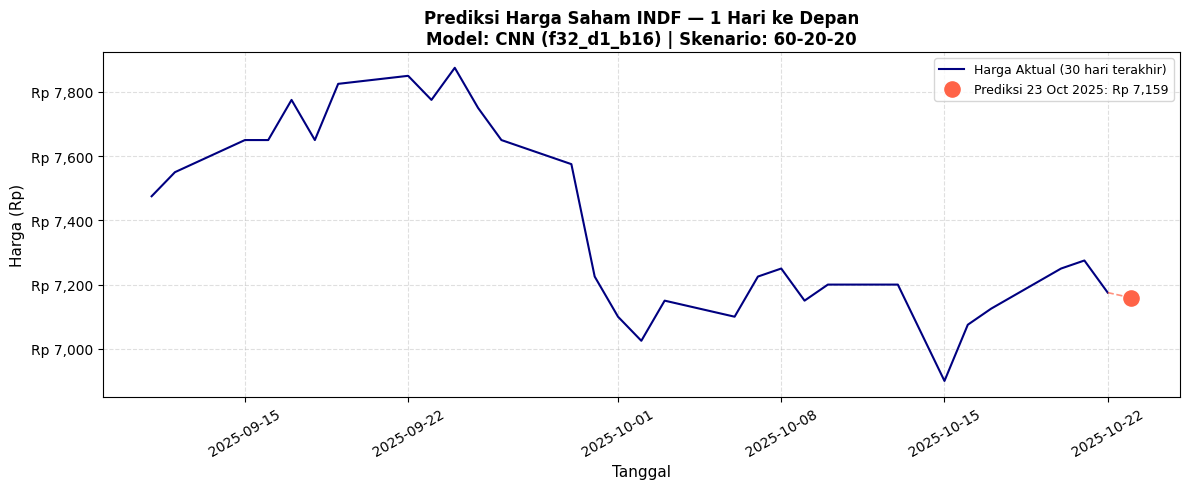

✅ Grafik prediksi 1 hari disimpan ke: 'prediksi_1hari_CNN.png'


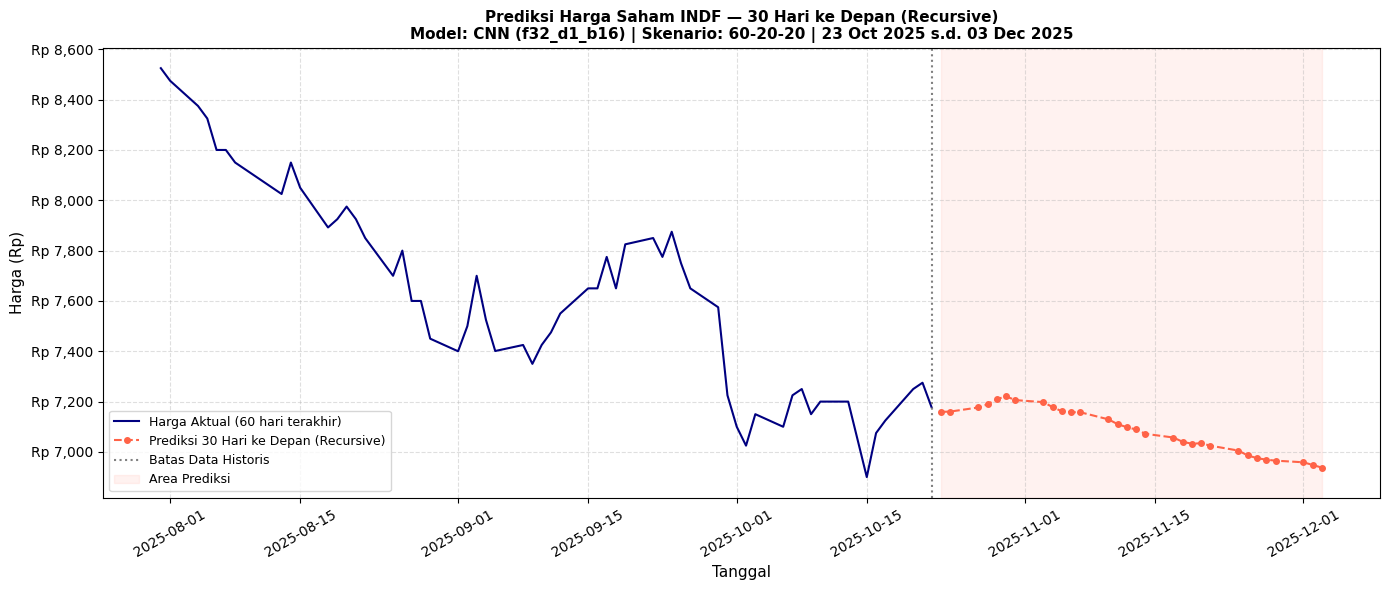

✅ Grafik prediksi 30 hari disimpan ke: 'prediksi_30hari_CNN.png'


In [11]:
# ============================================================
# CELL 13 — PREDIKSI 1 HARI & 30 HARI KE DEPAN (RECURSIVE)
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DAYS_AHEAD = 30

# ── Definisi variabel yang dibutuhkan ──
model_terbaik      = model_final[best_key]
scaler_terbaik     = datasets[best_skenario]['scaler']
data_close_full    = df[['Close']].values
last_window_raw    = data_close_full[-WINDOW_SIZE:]
last_window_scaled = scaler_terbaik.transform(last_window_raw)
tanggal_terakhir   = df.index[-1]

# 1. Window awal
current_window = last_window_scaled.copy()  # shape (30, 1)

# 2. Prediksi rekursif
prediksi_list = []

for hari in range(DAYS_AHEAD):
    X_input = current_window.reshape(1, WINDOW_SIZE, 1)
    pred    = model_terbaik.predict(X_input, verbose=0)[0][0]
    prediksi_list.append(pred)

    # Hasil prediksi dianggap aktual → geser window
    new_point      = np.array([[pred]])
    current_window = np.concatenate([current_window[1:], new_point], axis=0)

# 3. Inverse transform → satuan Rupiah
prediksi_scaled_arr = np.array(prediksi_list).reshape(-1, 1)
prediksi_rupiah_arr = scaler_terbaik.inverse_transform(prediksi_scaled_arr).flatten()

# 4. Buat daftar tanggal prediksi (hari kerja)
tanggal_awal = tanggal_terakhir + pd.offsets.BDay(1)
tanggal_pred = pd.date_range(start=tanggal_awal, periods=DAYS_AHEAD, freq='B')

# ============================================================
# OUTPUT 1 — PREDIKSI 1 HARI KE DEPAN (23 Oktober 2025)
# ============================================================
pred_1hari     = prediksi_rupiah_arr[0]
tanggal_1hari  = tanggal_pred[0]
harga_terakhir = data_close_full[-1][0]
selisih        = pred_1hari - harga_terakhir
arah           = "naik" if selisih >= 0 else "turun"

print("=" * 55)
print("  PREDIKSI HARGA SAHAM INDF — 1 HARI KE DEPAN")
print("=" * 55)
print(f"  Model            : {best_key}")
print(f"  Data terakhir    : {tanggal_terakhir.strftime('%d %B %Y')} "
      f"| Harga: Rp {harga_terakhir:,.0f}")
print(f"  Tanggal prediksi : {tanggal_1hari.strftime('%d %B %Y')}")
print(f"  Prediksi Harga   : Rp {pred_1hari:,.2f}")
print(f"  Selisih          : Rp {abs(selisih):,.2f} ({arah})")
print("=" * 55)

# ============================================================
# OUTPUT 2 — PREDIKSI 30 HARI KE DEPAN
# ============================================================
df_prediksi_30 = pd.DataFrame({
    'Tanggal'       : tanggal_pred.strftime('%d %B %Y'),
    'Prediksi (Rp)' : prediksi_rupiah_arr.round(2)
})

print("\n" + "=" * 55)
print("  PREDIKSI HARGA SAHAM INDF — 30 HARI KE DEPAN")
print("=" * 55)
print(f"  Model    : {best_key}")
print(f"  Strategi : Recursive Forecasting")
print(f"  Mulai    : {tanggal_pred[0].strftime('%d %B %Y')}")
print(f"  Selesai  : {tanggal_pred[-1].strftime('%d %B %Y')}")
print("=" * 55)
print(df_prediksi_30.to_string(index=False))

df_prediksi_30.to_csv('prediksi_30hari_CNN.csv', index=False)
print("\n✅ Hasil disimpan ke: 'prediksi_30hari_CNN.csv'")

# ============================================================
# VISUALISASI 1 — 1 Hari ke Depan
# ============================================================
fig, ax = plt.subplots(figsize=(12, 5))

tanggal_hist = df.index[-WINDOW_SIZE:]
harga_hist   = data_close_full[-WINDOW_SIZE:].flatten()

ax.plot(tanggal_hist, harga_hist,
        label='Harga Aktual (30 hari terakhir)',
        color='navy', linewidth=1.5)

label_1hari = f"Prediksi {tanggal_1hari.strftime('%d %b %Y')}: Rp {pred_1hari:,.0f}"
ax.scatter([tanggal_1hari], [pred_1hari],
           color='tomato', s=120, zorder=5, label=label_1hari)
ax.plot([tanggal_hist[-1], tanggal_1hari],
        [harga_hist[-1], pred_1hari],
        color='tomato', linestyle='--', linewidth=1.2, alpha=0.7)

ax.set_title(
    f'Prediksi Harga Saham INDF — 1 Hari ke Depan\n'
    f'Model: {best_label} | Skenario: {best_skenario}',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('Tanggal', fontsize=11)
ax.set_ylabel('Harga (Rp)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp {int(x):,}'))
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('prediksi_1hari_CNN.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik prediksi 1 hari disimpan ke: 'prediksi_1hari_CNN.png'")

# ============================================================
# VISUALISASI 2 — 30 Hari ke Depan
# ============================================================
LOOKBACK_VIS     = 60
tanggal_hist_vis = df.index[-LOOKBACK_VIS:]
harga_hist_vis   = data_close_full[-LOOKBACK_VIS:].flatten()

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(tanggal_hist_vis, harga_hist_vis,
        label='Harga Aktual (60 hari terakhir)',
        color='navy', linewidth=1.5)

ax.plot(tanggal_pred, prediksi_rupiah_arr,
        label='Prediksi 30 Hari ke Depan (Recursive)',
        color='tomato', linewidth=1.5,
        linestyle='--', marker='o', markersize=4)

ax.axvline(x=tanggal_terakhir, color='gray',
           linestyle=':', linewidth=1.5, label='Batas Data Historis')
ax.axvspan(tanggal_pred[0], tanggal_pred[-1],
           alpha=0.08, color='tomato', label='Area Prediksi')

tgl_mulai   = tanggal_pred[0].strftime('%d %b %Y')
tgl_selesai = tanggal_pred[-1].strftime('%d %b %Y')
ax.set_title(
    f'Prediksi Harga Saham INDF — 30 Hari ke Depan (Recursive)\n'
    f'Model: {best_label} | Skenario: {best_skenario} | '
    f'{tgl_mulai} s.d. {tgl_selesai}',
    fontsize=11, fontweight='bold'
)
ax.set_xlabel('Tanggal', fontsize=11)
ax.set_ylabel('Harga (Rp)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp {int(x):,}'))
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('prediksi_30hari_CNN.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik prediksi 30 hari disimpan ke: 'prediksi_30hari_CNN.png'")